# Extraction Pipeline

This notebook runs the full ingestion pipeline: recursive chunking, vector index construction,
triple extraction, entity resolution, validation, and Supermemory storage. Every expensive step
caches to `data/` so reruns skip completed work.

We are taking data from the first notebook outputs:  `data/schema.json`, `data/detected_chapters.json`, raw book texts in `data/`.

### Setup and Data Loading

In [1]:
from __future__ import annotations
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(Path("../.env"))
import json, os, re, sys
import nltk
nltk.download('punkt_tab', quiet=True)
sys.path.insert(0, str(Path("..").resolve()))
import instructor
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
import asyncio
from openai import OpenAI, AsyncOpenAI
from pydantic import BaseModel, Field
from src.models import (ChapterDetectionResult, EntityType, ExtractionResponse,OntologySchema, RelationshipType, Triple)
from supermemory import Supermemory

In [2]:
data_dir: Path = Path("../data")

book_metadata: dict[str, dict[str, str]] = {
    "shakespeare_complete": {"title": "Complete Works of Shakespeare", "author": "William Shakespeare", "genre": "Drama / Poetry"},
    "beowulf": {"title": "Beowulf", "author": "Anonymous", "genre": "Epic Poetry"},
    "prince": {"title": "The Prince", "author": "Niccolo Machiavelli", "genre": "Political Philosophy"},
    "count_of_monte_cristo": {"title": "The Count of Monte Cristo", "author": "Alexandre Dumas", "genre": "Adventure"},
    "dracula": {"title": "Dracula", "author": "Bram Stoker", "genre": "Gothic Horror"},
    "frankenstein": {"title": "Frankenstein", "author": "Mary Shelley", "genre": "Gothic Horror / Sci-Fi"},
    "pride_and_prejudice": {"title": "Pride and Prejudice", "author": "Jane Austen", "genre": "Comedy of Manners"},
    "alice_in_wonderland": {"title": "Alice's Adventures in Wonderland", "author": "Lewis Carroll", "genre": "Fantasy"},
    "great_gatsby": {"title": "The Great Gatsby", "author": "F. Scott Fitzgerald", "genre": "Modernist Fiction"}}

In [3]:
def split_by_detected_chapters(text: str, result: ChapterDetectionResult, min_len: int = 200) -> list[tuple[str, str]]:
    """
    Split text at detected headings. Uses exact match for short headings to avoid false positives.
    """
    heading_set: set[str] = set(result.headings)
    lines: list[str] = text.split("\n")
    last_seen: dict[str, int] = {}
    char_pos: int = 0
    
    for line in lines:
        stripped: str = line.strip()
        matched = next(
            (h for h in heading_set
             if ((stripped == h) if len(h) <= 5 else (stripped.startswith(h) or h.startswith(stripped)))),
            None)
        if matched:
            last_seen[matched] = char_pos
        char_pos += len(line) + 1

    positions: list[tuple[int, str]] = sorted(((pos, h) for h, pos in last_seen.items()))
    chapters: list[tuple[str, str]] = []

    for i, (pos, heading) in enumerate(positions):
        end: int = positions[i + 1][0] if i + 1 < len(positions) else len(text)
        body: str = text[pos + len(heading):end].strip()
        if len(body) > min_len:
            chapters.append((heading, body))

    return chapters

In [4]:
schema = OntologySchema(**json.loads((data_dir / "schema.json").read_text()))

detected = {
    k: ChapterDetectionResult(**v)
    for k, v in json.loads((data_dir / "detected_chapters.json").read_text()).items()}

corpus: dict[str, str] = {
    key: (data_dir /"books"/f"{key}.txt").read_text(encoding="utf-8")
    for key in book_metadata}

book_chapters = {
    key: split_by_detected_chapters(text, detected[key])
    for key, text in corpus.items() if key in detected}

In [5]:
rows = []
for key in corpus:
    meta = book_metadata[key]
    n_ch = len(book_chapters.get(key, []))
    rows.append({"Book": meta["title"], "Words": len(corpus[key].split()), "Chapters": n_ch})
display(pd.DataFrame(rows))
print(f"\nSchema: {len(schema.entity_types)} entity types, "
      f"{len(schema.relationship_types)} relationship types")

,Book,Words,Chapters
0,Complete Works of Shakespeare,966506,43
1,Beowulf,42224,2
2,The Prince,52984,25
3,The Count of Monte Cristo,464025,116
4,Dracula,164356,14
5,Frankenstein,78106,17
6,Pride and Prejudice,130415,10
7,Alice's Adventures in Wonderland,29569,12
8,The Great Gatsby,51262,9



Schema: 8 entity types, 14 relationship types


## Recursive Chunking

Each chapter is split into chunks of approximately 512 tokens, using a 4:1 character-to-token
ratio as a fast approximation to avoid running a tokenizer on every split decision. Sentence
boundaries are detected with NLTK's Punkt tokenizer, which handles abbreviations and edge
cases that a simple regex split on punctuation would miss. Each chunk carries full provenance
metadata (book, author, chapter, position) so downstream agents can trace any retrieved
passage back to its source.

In [6]:
class Chunk(BaseModel):
    text: str
    book_id: str
    book_title: str
    author: str
    chapter_number: int
    chapter_title: str
    chunk_index: int
    total_chunks_in_chapter: int

In [7]:
def chunk_chapter(chapter_body: str, book_id: str, chapter_number: int,
                  chapter_title: str, *, max_tokens: int = 512, chars_per_token: float = 4.0) -> list[Chunk]:
    """
    Split a chapter into ~512-token chunks respecting sentence boundaries.
    """
    max_chars: int = int(max_tokens * chars_per_token)
    sentences: list[str] = nltk.sent_tokenize(chapter_body)
    meta: dict[str, str] = book_metadata[book_id]
    chunks: list[Chunk] = []
    current: list[str] = []
    current_len: int = 0

    def flush_chunk() -> None:
        if current:
            chunks.append(Chunk(
                text=" ".join(current), book_id=book_id,
                book_title=meta["title"], author=meta["author"],
                chapter_number=chapter_number, chapter_title=chapter_title,
                chunk_index=len(chunks), total_chunks_in_chapter=0))

    for sent in sentences:
        if current_len + len(sent) > max_chars and current:
            flush_chunk()
            current, current_len = [], 0
        current.append(sent)
        current_len += len(sent) + 1
    flush_chunk()
    for c in chunks:
        c.total_chunks_in_chapter = len(chunks)
    return chunks

In [8]:
def chunk_all_books(book_chapters: dict[str, list[tuple[str, str]]]) -> list[Chunk]:
    """
    It chunks all our books and then caches to data/recursive_chunks.json.
    """
    cache_path = data_dir / "recursive_chunks.json"

    if cache_path.exists():
        print(f"Loading cached chunks from {cache_path}")
        return [Chunk(**c) for c in json.loads(cache_path.read_text())]

    all_chunks: list[Chunk] = []
    for book_id, chapters in book_chapters.items():
        book_chunks: list[Chunk] = []

        for i, (heading, body) in enumerate(chapters):
            book_chunks.extend(chunk_chapter(body, book_id, i + 1, heading))
        all_chunks.extend(book_chunks)

    cache_path.write_text(json.dumps([c.model_dump() for c in all_chunks], ensure_ascii=False))    
    return all_chunks


chunks: list[Chunk] = chunk_all_books(book_chapters)

Loading cached chunks from ../data/recursive_chunks.json


Total chunks: 5937
Avg chunk size: 331 words
Min: 1, Max: 403


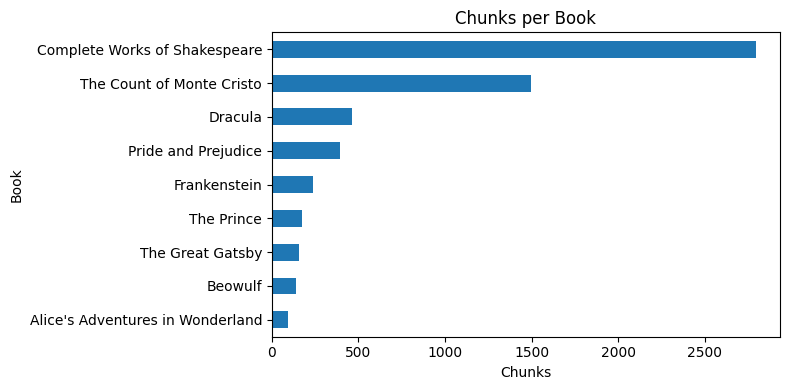

In [9]:
def display_chunk_stats(chunks: list[Chunk]) -> None:
    """
    Displaying chunk statistics and a bar chart of chunks per book.
    """
    df = pd.DataFrame([{"Book": c.book_title, "Words": len(c.text.split())} for c in chunks])
    print(f"Total chunks: {len(chunks)}")
    print(f"Avg chunk size: {df['Words'].mean():.0f} words")
    print(f"Min: {df['Words'].min()}, Max: {df['Words'].max()}")
    counts = df.groupby("Book").size().sort_values()
    counts.plot.barh(title="Chunks per Book", figsize=(8, 4))
    plt.xlabel("Chunks")
    plt.tight_layout()
    plt.show()


display_chunk_stats(chunks)

## Recursive Vector Index (BM25)

BM25 keyword search over the recursive chunks. These chunks have no injected context
words, keeping term frequencies clean for BM25 scoring. This index serves the Vector RAG
Agent for high-specificity factual queries where exact entity names appear in the query.

In [10]:
from rank_bm25 import BM25Okapi

def build_bm25_index(chunks: list[Chunk]) -> BM25Okapi:
    """
    It builds a BM25 index over recursive chunks using rank_bm25.
    """
    tokenized = [c.text.lower().split() for c in chunks]
    return BM25Okapi(tokenized)

bm25_index: BM25Okapi = build_bm25_index(chunks)

In [11]:
def query_bm25(query: str, index: BM25Okapi, chunks: list[Chunk], *, top_k: int = 5, book_id: str | None = None) -> list[tuple[Chunk, float]]:
    """
    Query BM25 index, optionally filtered by book.
    """
    scores = index.get_scores(query.lower().split())
    scored = list(zip(chunks, scores))

    if book_id:
        scored = [(c, s) for c, s in scored if c.book_id == book_id]
    scored.sort(key=lambda x: x[1], reverse=True)
    
    return scored[:top_k]

## Contextual Enrichment

For each recursive chunk, a lightweight model generates a one sentence contextual header
that resolves pronouns and ambiguous references. The enriched chunks are useful for the dense
semantic search index. The header is prepended to the chunk text before embedding so the
vector captures the full narrative context, not just the surface text.

In [12]:
batch_header_prompt = """Generate brief contextual headers for the following passages.
Each header should resolve pronouns and ambiguous references, helping a semantic
search engine understand what the passage is about without reading surrounding text.

{chunks_block}

For EACH passage, write ONE sentence starting with "This passage is from..." that
captures who is involved, what is happening, and where in the narrative this occurs.
Return the headers in order, one per passage.
"""

def format_chunks_block(batch: list) -> str:
    """
    Format a batch of chunks into a numbered prompt block.
    """
    sections: list[str] = []
    
    for i, chunk in enumerate(batch, 1):
        sections.append(
            f"### Passage {i}\n"
            f"Book: {chunk.book_title} by {chunk.author}\n"
            f"Chapter {chunk.chapter_number}: {chunk.chapter_title}\n"
            f"Chunk {chunk.chunk_index + 1} of {chunk.total_chunks_in_chapter}\n\n"
            f"{chunk.text}")

    return "\n\n".join(sections)

In [13]:
class BatchContextualHeaders(BaseModel):
    headers: list[str] = Field(description="Contextual headers in order, one per passage")

class EnrichedChunk(Chunk):
    contextual_header: str

In [14]:
async def enrich_batch(batch: list[Chunk], *, model: str, client: instructor.AsyncInstructor) -> list[EnrichedChunk]:
    """
    Generate contextual headers for a batch of chunks in a single LLM call.
    """
    resp: BatchContextualHeaders = await client.chat.completions.create(
        model=model, response_model=BatchContextualHeaders,
        temperature=0.1,
        messages=[{"role": "user", "content": batch_header_prompt.format(
            chunks_block=format_chunks_block(batch))}])
    return [
        EnrichedChunk(**chunk.model_dump(), contextual_header=header)
        for chunk, header in zip(batch, resp.headers)]

In [15]:
async def enrich_all_chunks(chunks: list[Chunk], *, model: str,
                            batch_size: int = 3, max_concurrent: int = 10) -> list[EnrichedChunk]:
    """
    Enrich all chunks with contextual headers using async batched calls.
    Processes batch_size chunks per LLM call with max_concurrent parallel requests.
    Saves incrementally to disk so interrupted runs can resume.
    """
    cache_path: Path = data_dir / "chunks" / "contextual_chunks.json"

    if cache_path.exists():
        cached: list[EnrichedChunk] = [EnrichedChunk(**c) for c in json.loads(cache_path.read_text())]
        if len(cached) >= len(chunks):
            print(f"Loading {len(cached)} cached enriched chunks")
            return cached[:len(chunks)]
    else:
        cached = []

    remaining: list[Chunk] = chunks[len(cached):]
    sem: asyncio.Semaphore = asyncio.Semaphore(max_concurrent)
    batches: list[list[Chunk]] = [remaining[i:i + batch_size] for i in range(0, len(remaining), batch_size)]
    wave_size: int = 34  # ~100 chunks per wave

    for w in range(0, len(batches), wave_size):
        client = instructor.from_openai(AsyncOpenAI(), mode=instructor.Mode.JSON)

        async def bounded(batch: list[Chunk]) -> list[EnrichedChunk]:
            async with sem:
                return await enrich_batch(batch, model=model, client=client)

        wave: list[list[Chunk]] = batches[w:w + wave_size]
        results: list[list[EnrichedChunk]] = await asyncio.gather(*[bounded(b) for b in wave])
        for batch_result in results:
            cached.extend(batch_result)
        cache_path.write_text(json.dumps([c.model_dump() for c in cached], ensure_ascii=False))
        print(f"  Enriched {len(cached)}/{len(chunks)} chunks (saved)")

    return cached
    

In [16]:
def load_cached_chunks(chunks: list[Chunk]) -> list[EnrichedChunk]:

    cache_path: Path = data_dir / "chunks" / "contextual_chunks.json"

    if cache_path.exists():
        cached: list[EnrichedChunk] = [EnrichedChunk(**c) for c in json.loads(cache_path.read_text())]
        if len(cached) >= len(chunks):
            print(f"Loading {len(cached)} cached enriched chunks")
            return cached[:len(chunks)]
    else:
        cached = []
    return cached

load_cached_chunks(chunks)

Loading 5941 cached enriched chunks


[EnrichedChunk(text='1\n\n\n\n\n\nFrom fairest creatures we desire increase,\n\n\nThat thereby beauty’s rose might never die,\n\n\nBut as the riper should by time decease,\n\n\nHis tender heir might bear his memory:\n\n\nBut thou contracted to thine own bright eyes,\n\n\nFeed’st thy light’s flame with self-substantial fuel,\n\n\nMaking a famine where abundance lies,\n\n\nThyself thy foe, to thy sweet self too cruel:\n\n\nThou that art now the world’s fresh ornament,\n\n\nAnd only herald to the gaudy spring,\n\n\nWithin thine own bud buriest thy content,\n\n\nAnd, tender churl, mak’st waste in niggarding:\n\n\n  Pity the world, or else this glutton be,\n\n\n  To eat the world’s due, by the grave and thee. 2\n\n\n\n\n\nWhen forty winters shall besiege thy brow,\n\n\nAnd dig deep trenches in thy beauty’s field,\n\n\nThy youth’s proud livery so gazed on now,\n\n\nWill be a tattered weed of small worth held:\n\n\nThen being asked, where all thy beauty lies,\n\n\nWhere all the treasure of th

## Contextual Vector Index (Dense)

Dense semantic search over enriched chunks. Each chunk is embedded as `header + text`
using Vertex AI text-embedding-005 with asymmetric task types: `RETRIEVAL_DOCUMENT` at
index time, `RETRIEVAL_QUERY` at search time. We will then use cosine similarity with L2-Normalization over numpy arrays.

They will stay in memory, even though for production we would move to a vector database. We are also working in batches, since the texts are chunks are quite a lot and we don't want to hit API limits. Moreover, we want to retrieve onmly the failed butch in cass of possible failure. 

In [17]:
def embed_all_chunks(enriched: list[EnrichedChunk], *, embedding_model: TextEmbeddingModel, batch_size: int = 100) -> np.ndarray:
    """
    Embedding enriched chunks (header + text). Cached then to .npy file for later usage.
    """
    cache_path = data_dir / "contextual_embeddings.npy"

    if cache_path.exists():
        return np.load(cache_path)

    all_embeddings: list[list[float]] = []

    for i in range(0, len(enriched), batch_size):
        batch = enriched[i:i + batch_size]
        inputs = [TextEmbeddingInput(
            text=f"{c.contextual_header}\n\n{c.text}",
            task_type="RETRIEVAL_DOCUMENT") for c in batch]
        results = embedding_model.get_embeddings(inputs)
        all_embeddings.extend([r.values for r in results])

    arr = np.array(all_embeddings, dtype=np.float32)
    np.save(cache_path, arr)

    return arr

Now we write a testing function we will use later to run a few test queries and confirm the dense index returns good results before moving on to the agentic layer. 

In [18]:
def query_dense(query: str, embeddings: np.ndarray, chunks: list[EnrichedChunk], *, embedding_model: TextEmbeddingModel, top_k: int = 5, book_id: str | None = None) -> list[tuple[EnrichedChunk, float]]:
    """
    Dense cosine similarity search over contextual embeddings.
    """
    q_input = TextEmbeddingInput(text=query, task_type="RETRIEVAL_QUERY")
    q_vec = np.array(embedding_model.get_embeddings([q_input])[0].values, dtype=np.float32)
    norms = np.linalg.norm(embeddings, axis=1) * np.linalg.norm(q_vec)
    scores = (embeddings @ q_vec) / np.where(norms > 0, norms, 1.0)
    indices = np.argsort(scores)[::-1]

    results: list[tuple[EnrichedChunk, float]] = []

    for idx in indices:
        if book_id and chunks[idx].book_id != book_id:
            continue
        results.append((chunks[idx], float(scores[idx])))
        if len(results) >= top_k:
            break
        
    return results

## Triple Extraction

Extract schema-constrained triples from every recursive chunk. Each triple links a subject entity to an object entity through a typed relationship, grounded by the exact source text.

**Schema refinement:** after an initial extraction pass, CQ gap analysis revealed two missing edge types. Several competency questions ask about consequences ("what happened because of X "), which temporal ordering alone (PRECEDES) cannot answer. Others require grounding events at specific locations, which neither OCCURS_IN (Event - TextualComponent) nor SET_IN (LiteraryWork - Location) can express at event granularity.

We added CAUSES (Event - Event) and OCCURS_AT (Event - Location) to the schema, bringing the total to 14 relationship types. This is a standard post-extraction refinement in CQ-driven ontology engineering.

In [19]:
extraction_prompt = """You are a knowledge graph extraction system for literary texts.

## Schema
Entity types: {entity_types}
Relationship types (with source -> target constraints):
{relationship_details}

## Passage (from {book_title}, {chapter_title})
{passage}

## Task
Extract all (subject, predicate, object) triples from the passage.
Each triple MUST use entity types and relationship types from the schema above.
Each relationship MUST respect its source_type -> target_type constraint.

For each triple provide:
- subject / subject_type: entity name and its type from the schema
- predicate: relationship type from the schema
- object / object_type: entity name and its type from the schema
- confidence: 0.0 to 1.0
- source_text: the exact sentence(s) supporting this triple

Extract only triples explicitly supported by the passage text.
Return ONLY the structured response."""

In [20]:
async def extract_triples(passage: str, schema: OntologySchema, book_title: str, chapter_title: str, *, model: str, client: instructor.AsyncInstructor) -> ExtractionResponse:
    """
    Extracting schema-constrained triples from a single passage.
    """
    et_text: str = ", ".join(schema.entity_type_names())
    rt_details: str = "\n".join(f"  {rt.name}: {rt.source_type} -> {rt.target_type}"
        for rt in schema.relationship_types)

    return await client.chat.completions.create(
        model=model, response_model=ExtractionResponse, temperature=0.1,
        max_retries=2,
        messages=[{"role": "user", "content": extraction_prompt.format(
            entity_types=et_text, relationship_details=rt_details,
            book_title=book_title, chapter_title=chapter_title,
            passage=passage)}])

In [21]:
async def extract_all_triples(chunks: list[Chunk], schema: OntologySchema, *,
                              model: str, max_concurrent: int = 20) -> dict[str, list[dict]]:
    """
    Extract triples from all chunks, per book. Async with concurrent requests.
    Caches per book so interrupted runs skip completed books.
    """
    all_triples: dict[str, list[dict]] = {}

    for book_id in sorted({c.book_id for c in chunks}):
        cache_path: Path = data_dir / "triples" / "raw" / f"raw_triples_{book_id}.json"
        if cache_path.exists():
            all_triples[book_id] = json.loads(cache_path.read_text())
            continue

        sem: asyncio.Semaphore = asyncio.Semaphore(max_concurrent)
        book_chunks: list[Chunk] = [c for c in chunks if c.book_id == book_id]
        partial_path: Path = data_dir / "triples" / "raw" / f"raw_triples_{book_id}.partial.json"

        if partial_path.exists():
            triples: list[dict] = json.loads(partial_path.read_text())
            done_keys: set[tuple] = {(t["chapter_number"], t["chunk_index"]) for t in triples}
            book_chunks = [c for c in book_chunks if (c.chapter_number, c.chunk_index) not in done_keys]
        else:
            triples: list[dict] = []
        wave_size: int = 80

        for w in range(0, len(book_chunks), wave_size):
            client = instructor.from_openai(AsyncOpenAI(), mode=instructor.Mode.JSON)

            async def process_chunk(chunk: Chunk, bid: str = book_id, _client=client) -> list[dict]:
                async with sem:
                    try:
                        resp = await extract_triples(
                            chunk.text, schema, chunk.book_title,
                            chunk.chapter_title, model=model, client=_client)
                        results: list[dict] = []
                        for t in resp.triples:
                            d: dict = t.model_dump()
                            d.update(book_id=bid, chapter_number=chunk.chapter_number,
                                     chunk_index=chunk.chunk_index)
                            results.append(d)
                        return results
                    except Exception as e:
                        return []

            wave: list[Chunk] = book_chunks[w:w + wave_size]
            results: list[list[dict]] = await asyncio.gather(*[process_chunk(c) for c in wave])
            
            for chunk_triples in results:
                triples.extend(chunk_triples)
            partial_path.write_text(json.dumps(triples, ensure_ascii=False))
            print(f"  {book_id}: {min(w + wave_size, len(book_chunks))}/{len(book_chunks)} chunks (saved)")

        cache_path.write_text(json.dumps(triples, ensure_ascii=False))
        partial_path.unlink(missing_ok=True)
        all_triples[book_id] = triples

    return all_triples

**Note on Shakespeare:** Triple extraction for `shakespeare_complete` was interrupted by an
inference rate limit during processing. The partial results exist (`raw_triples_shakespeare_complete.json`)
but are incomplete and excluded from downstream steps. The remaining 8 books cover all target
genres (gothic horror, comedy of manners, epic poetry, adventure, fantasy, political philosophy,
modernist fiction) and provide sufficient volume (~37K triples, ~24K entity pairs) for the
knowledge graph and evaluation dataset. Shakespeare can be added in a future pass without
affecting the pipeline design.

In [22]:
excluded_books: set[str] = {"shakespeare_complete"}

def load_completed_triples() -> dict[str, list[dict]]:
    """
    Load raw triples from cache, excluding incomplete books.
    """
    raw_dir: Path = data_dir / "triples" / "raw"
    all_triples: dict[str, list[dict]] = {}

    for book_id in book_metadata:
        if book_id in excluded_books:
            continue
        cache_path = raw_dir / f"raw_triples_{book_id}.json"
        if cache_path.exists():
            all_triples[book_id] = json.loads(cache_path.read_text())

    return all_triples


all_triples: dict[str, list[dict]] = load_completed_triples()
print(f"Loaded {len(all_triples)} books, "
      f"{sum(len(t) for t in all_triples.values())} total triples")

Loaded 8 books, 37051 total triples


,Book,Triples
2,The Count of Monte Cristo,17223
3,Dracula,5811
5,Pride and Prejudice,4655
4,Frankenstein,2786
7,The Great Gatsby,2018
1,The Prince,1970
0,Beowulf,1559
6,Alice's Adventures in Wonderland,1029



Total triples: 37051


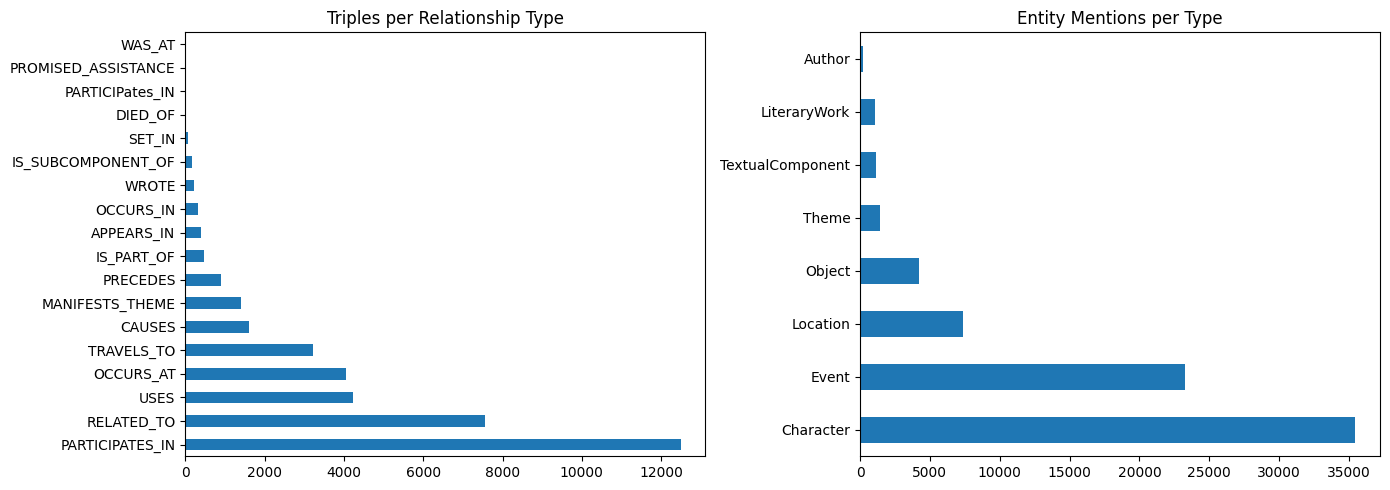

In [23]:
def display_extraction_stats(all_triples: dict[str, list[dict]]) -> None:
    """
    Display extraction statistics with charts for relationship types and entity mentions.
    """
    rows: list[dict] = []
    
    for book_id, triples in all_triples.items():
        rows.append({"Book": book_metadata[book_id]["title"], "Triples": len(triples)})

    display(pd.DataFrame(rows).sort_values("Triples", ascending=False))
    flat: list[dict] = [t for ts in all_triples.values() for t in ts]
    print(f"\nTotal triples: {len(flat)}")
    rel_counts = pd.Series([t["predicate"] for t in flat]).value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    rel_counts.plot.barh(ax=axes[0], title="Triples per Relationship Type")
    ent_types: list[str] = [t["subject_type"] for t in flat] + [t["object_type"] for t in flat]
    pd.Series(ent_types).value_counts().plot.barh(ax=axes[1], title="Entity Mentions per Type")
    plt.tight_layout()
    plt.show()

display_extraction_stats(all_triples)

## Alias Generation

For each unique entity extracted per book, a lightweight model generates alternative names,
titles, and descriptive references. These aliases feed the entity resolution step: without them,
RapidFuzz has no reference set to match against, and surface-form variations become orphan
nodes in the graph.

In [24]:
load_dotenv(Path("../.env"))

from google import genai
from google.genai import types

gc: genai.Client = genai.Client(vertexai=True, project=os.environ["gcp_project"], location="us-central1")
alias_model: str = "gemini-2.5-flash"
validation_model: str = "gemini-2.5-flash"
entity_min_frequency: int = 2
max_concurrency: int = 5

In [25]:
batch_alias_prompt = """For each entity from {book_title}, list 3-5 alternative names
a reader might use: titles, epithets, descriptive references ("the ring-giver",
"king of the Danes"), relational references ("Healfdene's son"), or shortened names.
NOT spelling variations.

Entities:
{entities_block}

Return JSON: {{"results": [{{"name": "X", "aliases": ["a", "b"]}}]}}"""


In [26]:
class EntityAliases(BaseModel):
    name: str = Field(description="Entity name as given in input")
    aliases: list[str] = Field(description="Alternative names, titles, and references")

class BatchAliasResponse(BaseModel):
    entities: list[EntityAliases]

class EntityWithAliases(BaseModel):
    canonical_name: str
    entity_type: str
    book_id: str
    aliases: list[str]

In [27]:
async def generate_aliases_batch(entities: list[tuple[str, str]], book_id: str, *, model: str) -> list[EntityWithAliases]:
    """Generate aliases for a batch of entities via Gemini. Runs sync call in thread with timeout + retry."""
    block: str = "\n".join(f"{i+1}. {name} ({etype})" for i, (name, etype) in enumerate(entities))
    prompt: str = batch_alias_prompt.format(book_title=book_metadata[book_id]["title"], entities_block=block)

    for attempt in range(3):
        try:
            resp = await asyncio.wait_for(
                asyncio.to_thread(gc.models.generate_content, model=model, contents=prompt,
                                  config=types.GenerateContentConfig(temperature=0.2, response_mime_type="application/json")),
                timeout=60)
            break
        except asyncio.TimeoutError:
            if attempt < 2:
                await asyncio.sleep(5 * (attempt + 1))
                continue
            raise
        except Exception as e:
            if "429" in str(e) and attempt < 2:
                await asyncio.sleep(5 * 2 ** attempt)
                continue
            raise

    data = json.loads(resp.text)
    raw: list[dict] = data if isinstance(data, list) else data.get("results", data.get("entities", []))
    results: list[EntityWithAliases] = []

    for item, (name, etype) in zip(raw, entities):
        aliases: list[str] = item.get("aliases", []) if isinstance(item, dict) else []
        results.append(EntityWithAliases(canonical_name=name, entity_type=etype, book_id=book_id, aliases=aliases))

    return results

In [28]:
sem: asyncio.Semaphore = asyncio.Semaphore(max_concurrency)

async def generate_aliases_batch_throttled(entities: list[tuple[str, str]], book_id: str, *, model: str, batch_num: int = 0, total_batches: int = 0) -> list[EntityWithAliases]:
    """Throttled wrapper around generate_aliases_batch."""
    async with sem:
        result = await generate_aliases_batch(entities, book_id, model=model)
        if batch_num % 10 == 0 or batch_num == total_batches - 1:
            print(f"    {book_id}: batch {batch_num+1}/{total_batches} done")
        return result

async def generate_all_aliases(all_triples: dict[str, list[dict]], *, model: str, batch_size: int = 15, min_frequency: int = entity_min_frequency) -> dict[str, list[EntityWithAliases]]:
    """Generate aliases for all entities appearing in min_frequency+ triples. Concurrent batches.
    """
    all_aliases: dict[str, list[EntityWithAliases]] = {}

    for book_id, triples in all_triples.items():
        cache_path: Path = data_dir / "aliases" / f"aliases_{book_id}.json"
        if cache_path.exists() and cache_path.stat().st_size > 10:
            print(f"  {book_id}: loading from cache")
            all_aliases[book_id] = [EntityWithAliases(**e) for e in json.loads(cache_path.read_text())]
            continue

        from collections import Counter
        counts: Counter = Counter()
        type_map: dict[str, str] = {}

        for t in triples:
            counts[t["subject"]] += 1; counts[t["object"]] += 1
            type_map[t["subject"]] = t["subject_type"]; type_map[t["object"]] = t["object_type"]

        entity_list: list[tuple[str, str]] = [(name, type_map[name]) for name, c in counts.items() if c >= min_frequency]
        print(f"  {book_id}: {len(entity_list)} entities (>={min_frequency} mentions)")

        batches: list[list[tuple[str, str]]] = [entity_list[i:i + batch_size] for i in range(0, len(entity_list), batch_size)]
        tasks = [generate_aliases_batch_throttled(batch, book_id, model=model, batch_num=i, total_batches=len(batches)) for i, batch in enumerate(batches)]
        batch_results: list[list[EntityWithAliases]] = await asyncio.gather(*tasks, return_exceptions=True)
        results: list[EntityWithAliases] = []

        for b_idx, br in enumerate(batch_results):
            if isinstance(br, Exception): print(f"    batch {b_idx+1} failed: {br}")
            else: results.extend(br)

        cache_path.parent.mkdir(parents=True, exist_ok=True)
        cache_path.write_text(json.dumps([e.model_dump() for e in results], ensure_ascii=False))
        print(f"  {book_id}: {len(results)} entities with aliases")
        all_aliases[book_id] = results

    return all_aliases

all_aliases: dict[str, list[EntityWithAliases]] = await generate_all_aliases(all_triples, model=alias_model)

  beowulf: loading from cache
  prince: loading from cache
  count_of_monte_cristo: loading from cache
  dracula: loading from cache
  frankenstein: loading from cache
  pride_and_prejudice: loading from cache
  alice_in_wonderland: loading from cache
  great_gatsby: loading from cache


/var/folders/92/r9tmfz2j3f320tbngmgd7frm0000gn/T/ipykernel_14503/704526544.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


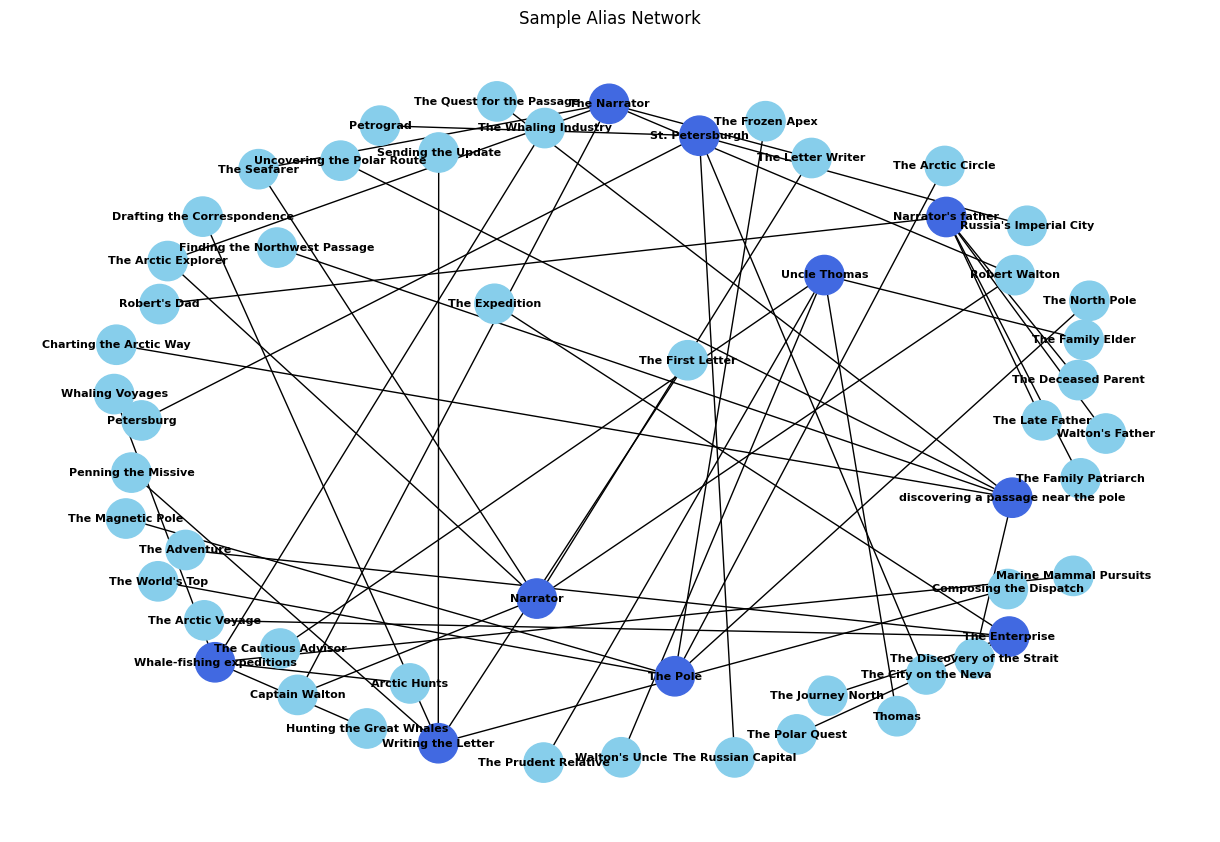

In [29]:
def display_alias_network(aliases: list[EntityWithAliases], max_entities: int = 10) -> None:
    """
    It displays a sample alias network using networkx.
    """
    G = nx.Graph()

    for entity in aliases[:max_entities]:
        G.add_node(entity.canonical_name, node_type="canonical")
        for alias in entity.aliases[:5]:
            G.add_node(alias, node_type="alias")
            G.add_edge(entity.canonical_name, alias)

    colors = ["#4169E1" if G.nodes[n].get("node_type") == "canonical"
              else "#87CEEB" for n in G.nodes]
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2, seed=42)
    nx.draw(G, pos, with_labels=True, node_color=colors,
            node_size=800, font_size=8, font_weight="bold")
    plt.title("Sample Alias Network")
    plt.tight_layout()
    plt.show()

display_alias_network(all_aliases["frankenstein"])

## Entity Resolution

Within each book, we merge duplicate entity nodes using RapidFuzz weighted ratio matching against
the alias index. This collapses surface form variations into same  nodes so the knowledge
graph has one node per real entity, not one node per name variant. The resolution happens per book
to prevent cross book entity confusion.

In [30]:
from rapidfuzz import fuzz

class ResolvedEntity(BaseModel):
    canonical_id: str
    canonical_name: str
    entity_type: str
    book_id: str
    merged_names: list[str]

In [31]:
def build_alias_index(aliases: list[EntityWithAliases]) -> dict[str, str]:
    """
    Build a flat alias -> canonical_name index for one book.
    """
    index: dict[str, str] = {}

    for entity in aliases:
        canonical = entity.canonical_name
        index[canonical.lower()] = canonical
        
        for alias in entity.aliases:
            index[alias.lower()] = canonical

    return index

In [32]:
def resolve_entities_in_book(triples: list[dict], alias_index: dict[str, str], book_id: str, *, threshold: int = 80) -> tuple[list[ResolvedEntity], dict[str, str]]:
    """
    Merge duplicate entities using RapidFuzz against the alias index.
    """
    name_map: dict[str, str] = {}
    all_names = {t["subject"] for t in triples} | {t["object"] for t in triples}

    for name in all_names:
        
        key = name.lower()

        if key in alias_index:
            name_map[name] = alias_index[key]
            continue
        best_match, best_score = None, 0

        for alias, canonical in alias_index.items():
            score = fuzz.WRatio(key, alias)
            if score > best_score:
                best_match, best_score = canonical, score

        name_map[name] = best_match if best_score >= threshold else name

    merged: dict[str, list[str]] = {}

    for original, canonical in name_map.items():
        merged.setdefault(canonical, []).append(original)

    entities = []

    for name, names in merged.items():
        etype = next(
            (t["subject_type"] for t in triples if t["subject"] == name),
            next((t["object_type"] for t in triples if t["object"] == name), "Unknown"))
        entities.append(ResolvedEntity(
            canonical_id=f"{book_id}::{name}", canonical_name=name,
            entity_type=etype, book_id=book_id, merged_names=names))
        
    return entities, name_map

In [33]:
def update_triples_with_resolved(triples: list[dict], name_map: dict[str, str]) -> list[dict]:
    """
    Replace entity names in triples with resolved canonical names.
    """
    updated: list[dict] = []

    for t in triples:
        t_new = t.copy()
        t_new["subject"] = name_map.get(t["subject"], t["subject"])
        t_new["object"] = name_map.get(t["object"], t["object"])
        updated.append(t_new)
        
    return updated

resolved_triples: dict[str, list[dict]] = {}
resolved_entities: dict[str, list[ResolvedEntity]] = {}

for book_id, triples in all_triples.items():
    alias_idx = build_alias_index(all_aliases[book_id])
    entities, name_map = resolve_entities_in_book(triples, alias_idx, book_id)
    resolved_entities[book_id] = entities
    resolved_triples[book_id] = update_triples_with_resolved(triples, name_map)

**Room for improvement**: We don't know how accurate the rapid fuzz mathcing is. We should run entity resolution with different thresholds (60, 70, 80, 90), count correct vs wrong merges at each threshold and pick the one that maximizes precision without losing too much recall. At that point the threshold is data driven and not a guess anymore.  

In [34]:
def display_resolution_stats(original: dict[str, list[dict]], resolved: dict[str, list[ResolvedEntity]]) -> None:
    """
    Display entity count before and after resolution per book.
    """
    rows: list[dict] = []
    
    for book_id in original:
        orig_names: set[str] = {t["subject"] for t in original[book_id]} | {t["object"] for t in original[book_id]}
        res_count: int = len(resolved.get(book_id, []))
        rows.append({"Book": book_metadata[book_id]["title"],
                      "Before": len(orig_names), "After": res_count,
                      "Merged": len(orig_names) - res_count})
    display(pd.DataFrame(rows))

display_resolution_stats(all_triples, resolved_entities)

,Book,Before,After,Merged
0,Beowulf,1354,581,773
1,The Prince,1821,791,1030
2,The Count of Monte Cristo,10275,4284,5991
3,Dracula,3921,1668,2253
4,Frankenstein,2184,900,1284
5,Pride and Prejudice,2412,1054,1358
6,Alice's Adventures in Wonderland,779,366,413
7,The Great Gatsby,1468,708,760


## Supermemory Storage

Store raw triples directly into Supermemory with per-book containers (`book_{key}`). Each
memory entry carries the source chunk text as content and the full triple metadata. The
content field holds the source text, not the triple label, because bare triples lose ~35%
of answer-relevant information.

In [ ]:
sm = Supermemory(api_key=os.environ["sup_key"])

# graph_search reads book_title from metadata but raw triples only have book_id
# this lookup fills that gap so passage objects render correctly downstream
book_titles = {
    "alice_in_wonderland": "Alice's Adventures in Wonderland", "beowulf": "Beowulf",
    "count_of_monte_cristo": "The Count of Monte Cristo", "dracula": "Dracula",
    "frankenstein": "Frankenstein", "great_gatsby": "The Great Gatsby",
    "pride_and_prejudice": "Pride and Prejudice", "prince": "The Prince",
    "shakespeare_complete": "Shakespeare Complete Works",
}

def store_triple(triple: dict, sm_client: Supermemory, container: str) -> str:
    """
    store a single raw triple as a memory entry in supermemory.
    """
    content = triple["source_text"]
    book_id = triple.get("book_id", "")
    # supermemory metadata only accepts str, float, bool, or list[str]
    metadata = {"entity_from": triple["subject"], "entity_from_type": triple["subject_type"],
                "relationship": triple["predicate"], "entity_to": triple["object"],
                "entity_to_type": triple["object_type"], "book_id": book_id,
                "book_title": book_titles.get(book_id, book_id),
                "chapter_number": float(triple.get("chapter_number", 0)),
                "chunk_index": float(triple.get("chunk_index", 0)),
                "confidence": float(triple.get("confidence", 0.0))}
    result = sm_client.add(content=content, metadata=metadata, container_tags=[container])
    return result.id

In [ ]:
def store_all_triples(all_triples: dict[str, list[dict]], sm_client: Supermemory) -> dict[str, int]:
    """
    store all raw triples into supermemory book containers.
    """
    counts: dict[str, int] = {}

    for book_id, triples in all_triples.items():
        container = f"book_{book_id}"

        for i, t in enumerate(triples):
            store_triple(t, sm_client, container)
            if (i + 1) % 200 == 0:
                print(f"    {book_id}: {i + 1}/{len(triples)}")

        counts[container] = len(triples)
        print(f"  {container}: {len(triples)} triples stored")
        
    return counts

counts = store_all_triples(resolved_triples, sm)

In [ ]:
def verify_storage(sm_client: Supermemory, container: str, query: str) -> None:
    """
    run a test query against a supermemory container to confirm triples are searchable.
    """
    results = sm_client.search.execute(q=query, container_tags=[container], limit=3)
    print(f"container: {container}")
    print(f"query: {query}")
    print(f"results: {len(results.results)}")
    for i, r in enumerate(results.results):
        print(f"\n  [{i + 1}] score: {r.score:.3f}")
        print(f"      content: {(r.content or '')[:200]}...")
        print(f"      metadata: {r.metadata}")

verify_storage(sm, "book_frankenstein", "Who is Victor Frankenstein?")